# Notebook 6: ResNet-18 — Deeper Architecture

**Goal:** Show that a deeper CNN architecture significantly outperforms our SimpleCNN.

ResNet (Residual Network) introduced **skip connections** that allow gradients to flow
directly through the network, solving the vanishing gradient problem and enabling
much deeper networks. ResNet-18 has 18 layers vs our SimpleCNN's 4 conv layers.

---

## 6.1 Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from src.data_utils import get_cifar10_loaders, get_raw_cifar10, CIFAR10_CLASSES
from src.models import cifar_resnet18, count_parameters
from src.train import train_model, evaluate, evaluate_with_probs
from src.visualize import (plot_training_curves, plot_confusion_matrix,
                           plot_per_class_accuracy, plot_misclassified, plot_roc_curves)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 6.2 What is ResNet?

The key insight of ResNet is the **residual connection** (skip connection):

```
Standard block:    x → [Conv → BN → ReLU → Conv → BN] → output
Residual block:    x → [Conv → BN → ReLU → Conv → BN] + x → ReLU → output
                                                         ↑
                                                    skip connection
```

The `+ x` adds the original input directly to the output. This means:
- Gradients can flow directly through the skip connection (no vanishing gradient)
- The layers only need to learn the *residual* (difference from identity)
- If a layer isn't useful, it can learn to output zero and just pass the input through

We modify ResNet-18 for CIFAR-10's 32×32 images by using a 3×3 first conv (instead of 7×7) and removing the early max pooling.

In [2]:
# Same data setup as SimpleCNN for fair comparison
train_loader, test_loader = get_cifar10_loaders(
    batch_size=64, data_dir='../data', augment=True, num_workers=0
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

c:\Users\Prithvi Nair\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training batches: 782
Test batches: 157


## 6.3 Model Architecture

In [3]:
model = cifar_resnet18(num_classes=10)

n_params = count_parameters(model)
print(f"ResNet-18 trainable parameters: {n_params:,}")
print(f"SimpleCNN had: 2,168,746 parameters")
print(f"ResNet-18 is {n_params / 2_168_746:.1f}x larger")
print()
print(model)

ResNet-18 trainable parameters: 11,173,962
SimpleCNN had: 2,168,746 parameters
ResNet-18 is 5.2x larger

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

## 6.4 Training

Same hyperparameters as SimpleCNN (30 epochs, Adam, lr=0.001) for a fair comparison.

In [4]:
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=30,
    lr=0.001,
    device=device
)

Training on: cuda
Epochs: 30, Learning Rate: 0.001
Model parameters: 11,173,962
------------------------------------------------------------
Epoch   1/30 | Train Loss: 1.3646 | Train Acc: 50.5% | Test Loss: 1.0899 | Test Acc: 62.0% | Time: 90.4s
Epoch   5/30 | Train Loss: 0.4937 | Train Acc: 83.0% | Test Loss: 0.4830 | Test Acc: 83.9% | Time: 101.0s
Epoch  10/30 | Train Loss: 0.3031 | Train Acc: 89.6% | Test Loss: 0.4060 | Test Acc: 86.3% | Time: 94.9s
Epoch  15/30 | Train Loss: 0.2018 | Train Acc: 93.0% | Test Loss: 0.3408 | Test Acc: 89.3% | Time: 91.7s
Epoch  20/30 | Train Loss: 0.1409 | Train Acc: 95.0% | Test Loss: 0.3742 | Test Acc: 89.6% | Time: 91.4s
Epoch  25/30 | Train Loss: 0.0617 | Train Acc: 97.8% | Test Loss: 0.3155 | Test Acc: 91.9% | Time: 91.6s
Epoch  30/30 | Train Loss: 0.0283 | Train Acc: 99.0% | Test Loss: 0.3371 | Test Acc: 92.7% | Time: 63.5s
------------------------------------------------------------
Best test accuracy: 92.7%
Total training time: 2747s (45.8 min

In [5]:
torch.save(model.state_dict(), '../saved_models/resnet18.pth')
print("Model saved to saved_models/resnet18.pth")

Model saved to saved_models/resnet18.pth


## 6.5 Training Curves

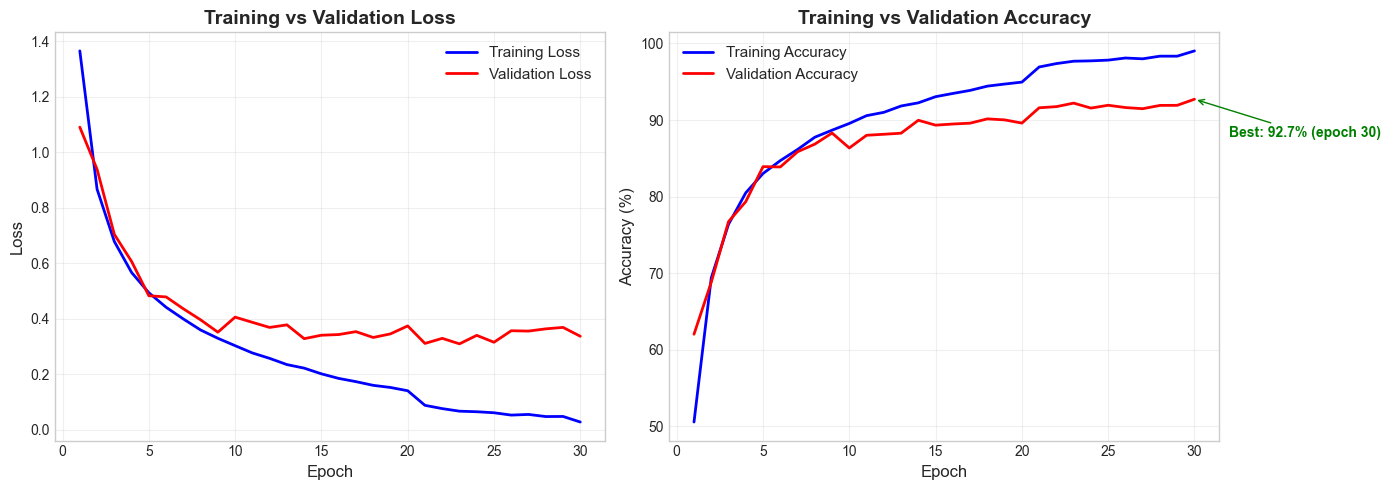

In [6]:
fig = plot_training_curves(history)
plt.show()

## 6.6 Test Set Evaluation

In [7]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, predictions, true_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"Final Test Results:")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")

Final Test Results:
  Test Loss:     0.3371
  Test Accuracy: 92.72%


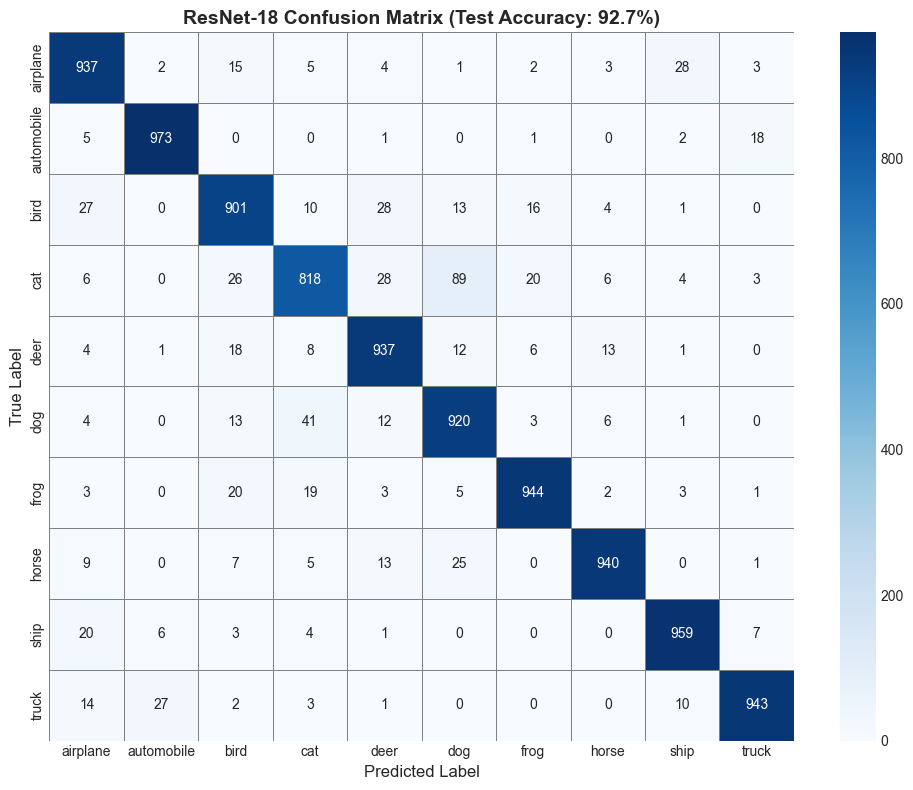

In [8]:
fig = plot_confusion_matrix(
    true_labels, predictions, CIFAR10_CLASSES,
    title=f'ResNet-18 Confusion Matrix (Test Accuracy: {test_acc:.1f}%)'
)
plt.show()

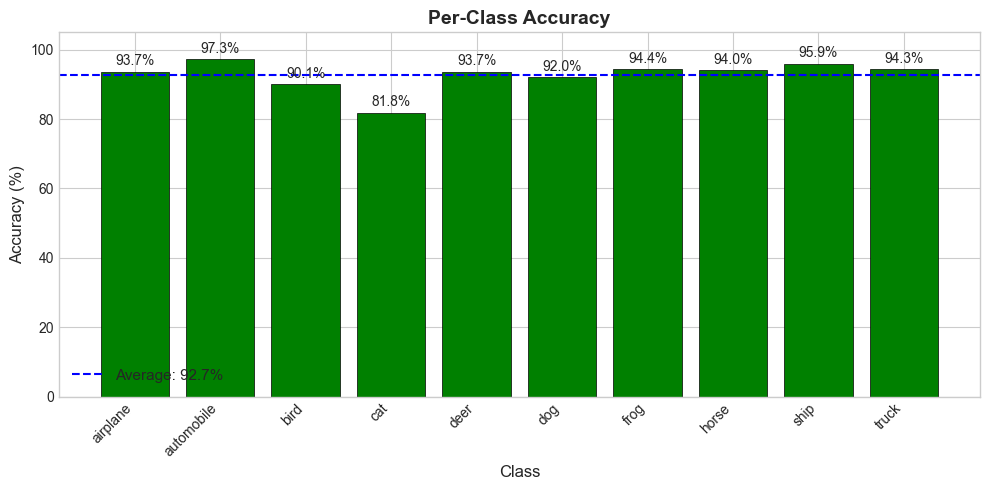

In [9]:
fig = plot_per_class_accuracy(true_labels, predictions, CIFAR10_CLASSES)
plt.show()

c:\Users\Prithvi Nair\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


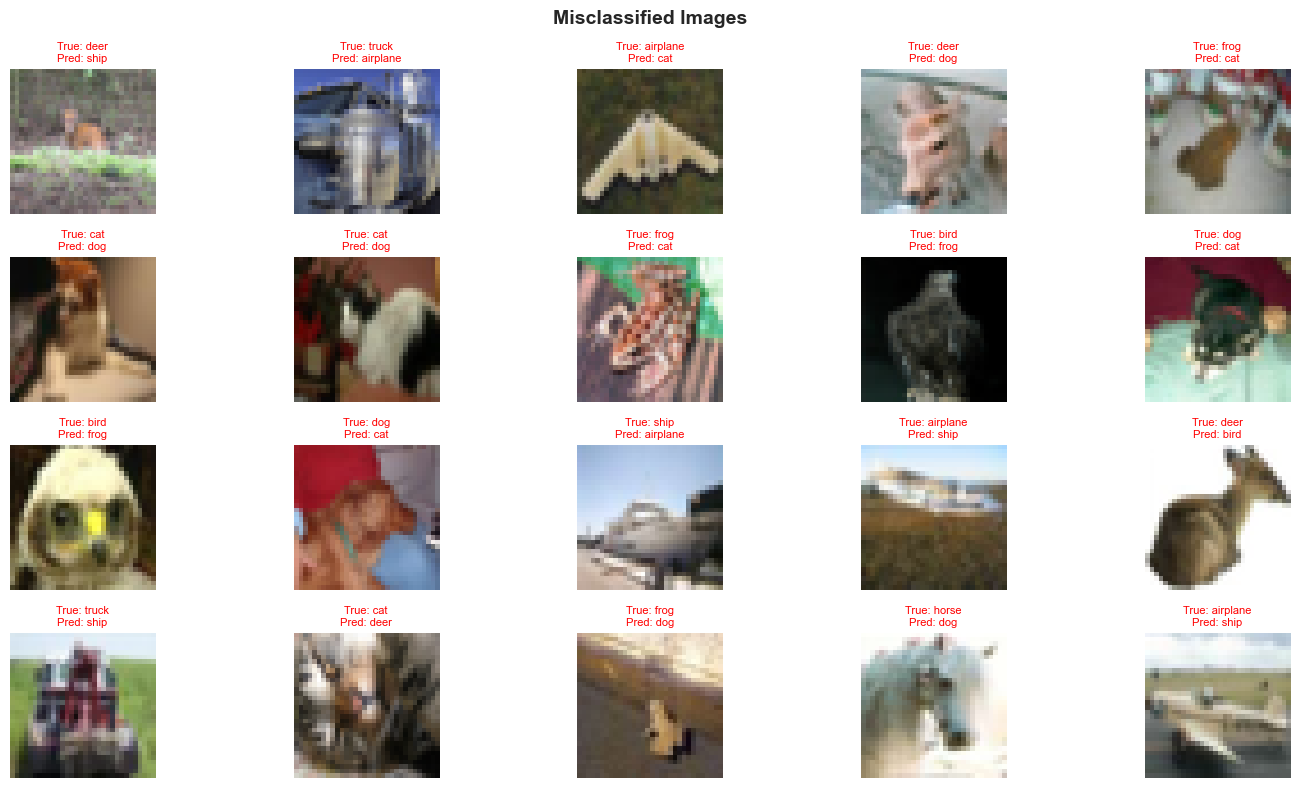

In [10]:
_, raw_test = get_raw_cifar10(data_dir='../data')
test_images = [np.array(raw_test[i][0]) for i in range(len(raw_test))]

fig = plot_misclassified(test_images, true_labels, predictions, CIFAR10_CLASSES, n=20)
plt.show()

## 6.7 ROC Curves

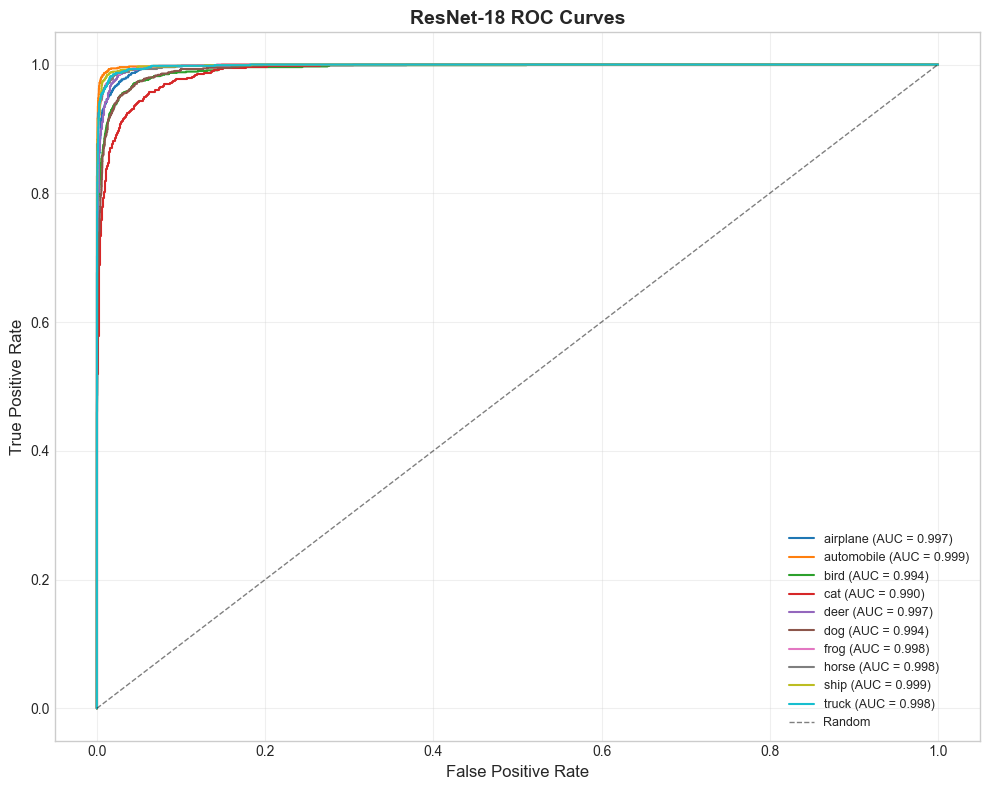

In [11]:
accuracy, preds, labels, probabilities = evaluate_with_probs(model, test_loader, device)

fig = plot_roc_curves(labels, probabilities, CIFAR10_CLASSES,
                      title=f'ResNet-18 ROC Curves')
plt.show()

## 6.8 Save Results

In [12]:
import json

resnet_results = {
    'accuracy': test_acc,
    'total_time': sum(history['epoch_times']),
    'epochs': len(history['train_loss']),
    'predictions': predictions,
    'true_labels': true_labels,
    'probabilities': probabilities.tolist(),
    'history': {
        'train_loss': history['train_loss'],
        'train_acc': history['train_acc'],
        'test_loss': history['test_loss'],
        'test_acc': history['test_acc']
    },
    'n_parameters': n_params
}

with open('../saved_models/resnet_results.json', 'w') as f:
    json.dump(resnet_results, f)

print(f"Results saved. Test accuracy: {test_acc:.2f}%")
print(f"Training time: {sum(history['epoch_times']):.0f}s ({sum(history['epoch_times'])/60:.1f} min)")

Results saved. Test accuracy: 92.72%
Training time: 2747s (45.8 min)


## 6.9 Summary

### ResNet-18 vs SimpleCNN:
- **Architecture:** 18 layers with skip connections vs 4 conv layers
- **Parameters:** ~11M vs ~2.2M (5x larger)
- **Key advantage:** Skip connections enable deeper networks without vanishing gradients
- **Takeaway:** A deeper architecture is the single biggest accuracy improvement — more important than training tricks or fancy optimizers